# DID:  Card-Krueger (1994) DID replication in Python

In [3]:
# Card-Krueger (1994) DID replication in Python

import io
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

# ------------------------------------------------
# 1. Load data online
# ------------------------------------------------
PRIMARY_URL = "https://www.stat.ucla.edu/projects/datasets/fastfood.dta"
FALLBACK_URL = "https://raw.githubusercontent.com/alopatina/Applied-Causal-Analysis/master/DinD_ex.dta"

def load_card_krueger():
    try:
        df = pd.read_stata(PRIMARY_URL)
        print(f"Loaded data from primary URL: {PRIMARY_URL}")
        return df
    except Exception as e1:
        print(f"Primary URL failed: {e1}")

    # Fallback: public GitHub mirror
    try:
        df = pd.read_stata(FALLBACK_URL)
        print(f"Loaded data from fallback URL: {FALLBACK_URL}")
        return df
    except Exception as e2:
        raise RuntimeError(
            "Both online sources failed.\n"
            f"Primary error: {e1}\n"
            f"Fallback error: {e2}"
        )

df = load_card_krueger()

print("Shape:", df.shape)
print("Columns:", list(df.columns)[:20], "...")

# ------------------------------------------------
# 2. Basic cleaning and variable construction (Adapted for fallback data)
# ------------------------------------------------
# The fallback dataset is already in a long format with 'fte' as employment,
# 'nj' as treatment status, and 'after' as the post-period indicator.

# Rename columns to match the general script's expectations
# (id, employment, treated, post)
df_renamed = df.rename(
    columns={
        "sheet": "id",
        "fte": "employment",
        "nj": "treated",
        "after": "post",
    }
)

# Convert relevant columns to appropriate types and ensure no missing values
df_renamed["id"] = df_renamed["id"].astype(int)
df_renamed["treated"] = df_renamed["treated"].astype(int)
df_renamed["post"] = df_renamed["post"].astype(int)

# Filter for relevant columns and drop rows with missing essential data
long_df = df_renamed[["id", "treated", "post", "employment"]].dropna(
    subset=["employment", "treated", "post"]
).copy()

print("\nLong data shape (after adaptation):", long_df.shape)
print(long_df.head())

# ------------------------------------------------
# 4. Manual DID estimate
# ------------------------------------------------
group_means = (
    long_df.groupby(["treated", "post"])["employment"]
    .mean()
    .rename("mean_employment")
    .reset_index()
)

print("\nGroup means:")
print(group_means)

mean_nj_pre  = group_means.query("treated == 1 and post == 0")["mean_employment"].iloc[0]
mean_nj_post = group_means.query("treated == 1 and post == 1")["mean_employment"].iloc[0]
mean_pa_pre  = group_means.query("treated == 0 and post == 0")["mean_employment"].iloc[0]
mean_pa_post = group_means.query("treated == 0 and post == 1")["mean_employment"].iloc[0]

did_est = (mean_nj_post - mean_nj_pre) - (mean_pa_post - mean_pa_pre)

print("\nManual DID estimate:")
print(f"DID = ({mean_nj_post:.3f} - {mean_nj_pre:.3f}) - ({mean_pa_post:.3f} - {mean_pa_pre:.3f}) = {did_est:.3f}")





# ------------------------------------------------
# 5. DID regression
# ------------------------------------------------
# employment_it = beta0 + beta1*post_t + beta2*treated_i + beta3*(post_t * treated_i) + error_it
# beta3 is the DID estimand

model = smf.ols("employment ~ post + treated + post:treated", data=long_df)
result = model.fit(cov_type="cluster", cov_kwds={"groups": long_df["id"]})

print("\nDID regression with store-clustered SEs:")
print(result.summary())

Primary URL failed: <urlopen error [Errno 111] Connection refused>
Loaded data from fallback URL: https://raw.githubusercontent.com/alopatina/Applied-Causal-Analysis/master/DinD_ex.dta
Shape: (698, 6)
Columns: ['sheet', 'fte', 'nj', 'after', 'njafter', 'dfte'] ...

Long data shape (after adaptation): (698, 4)
   id  treated  post  employment
0   1        1     0        31.0
1   1        1     1        40.0
2   2        1     0        13.0
3   2        1     1        12.5
4   3        1     0        12.5

Group means:
   treated  post  mean_employment
0        0     0        20.299999
1        0     1        18.253845
2        1     0        17.301056
3        1     1        17.583628

Manual DID estimate:
DID = (17.584 - 17.301) - (18.254 - 20.300) = 2.329

DID regression with store-clustered SEs:
                            OLS Regression Results                            
Dep. Variable:             employment   R-squared:                       0.009
Model:                           

# Synethic Control: California Proposition 99

In [4]:
# California Proposition 99 synthetic control
# with intercept + in-space placebo/randomization test
# -----------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ============================================================
# 1. Load data online
# ============================================================
DATA_URL = "https://raw.githubusercontent.com/synth-inference/synthdid/master/data/california_prop99.csv"

df = pd.read_csv(DATA_URL, sep=";")
df.columns = [c.strip() for c in df.columns]

required = ["State", "Year", "PacksPerCapita", "treated"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["PacksPerCapita"] = pd.to_numeric(df["PacksPerCapita"], errors="coerce")
df["treated"] = pd.to_numeric(df["treated"], errors="coerce")
df = df.dropna(subset=["State", "Year", "PacksPerCapita"]).copy()

print("Loaded data shape:", df.shape)
print(df.head())
print(df['State'].unique())
print(len(df['State'].unique()))

Loaded data shape: (1209, 4)
         State  Year  PacksPerCapita  treated
0      Alabama  1970       89.800003        0
1     Arkansas  1970      100.300003        0
2     Colorado  1970      124.800003        0
3  Connecticut  1970      120.000000        0
4     Delaware  1970      155.000000        0
['Alabama' 'Arkansas' 'Colorado' 'Connecticut' 'Delaware' 'Georgia'
 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky' 'Louisiana'
 'Maine' 'Minnesota' 'Mississippi' 'Missouri' 'Montana' 'Nebraska'
 'Nevada' 'New Hampshire' 'New Mexico' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'West Virginia' 'Wisconsin' 'Wyoming' 'California']
39


In [6]:

# ============================================================
# 2. Helper: fit synthetic control with intercept
#    minimize || X1 - alpha - X0 w ||^2
#    s.t. w_j >= 0, sum_j w_j = 1
# ============================================================
def fit_scm_with_intercept(panel_df, treated_state, treatment_year):
    """
    panel_df: long dataframe with columns State, Year, PacksPerCapita
    treated_state: state name to treat as treated
    treatment_year: first treated year

    Returns:
        dict with fitted path, gap, weights, intercept, RMSPEs, etc.
    """
    # Pivot to year x state matrix
    Y = panel_df.pivot(index="Year", columns="State", values="PacksPerCapita").sort_index()

    if treated_state not in Y.columns:
        raise ValueError(f"{treated_state} not in panel.")

    # Keep states with complete pre-treatment data
    pre_years_all = Y.index[Y.index < treatment_year]
    if len(pre_years_all) == 0:
        raise ValueError("No pre-treatment years available.")

    donor_states = [s for s in Y.columns if s != treated_state]
    good_donors = [s for s in donor_states if Y.loc[pre_years_all, s].notna().all()]

    keep_states = [treated_state] + good_donors
    Y = Y[keep_states].copy()

    # Drop any year with missing values among retained states
    Y = Y.dropna(axis=0, how="any")

    pre_years = Y.index[Y.index < treatment_year]
    post_years = Y.index[Y.index >= treatment_year]

    if len(pre_years) == 0 or len(post_years) == 0:
        raise ValueError(f"{treated_state}: missing pre or post period after cleaning.")

    X1 = Y.loc[pre_years, treated_state].values
    X0 = Y.loc[pre_years, good_donors].values

    J = X0.shape[1]
    if J == 0:
        raise ValueError(f"{treated_state}: no usable donor states.")

    # theta = [alpha, w_1, ..., w_J]
    theta0 = np.zeros(J + 1)
    theta0[1:] = 1.0 / J

    def objective(theta):
        alpha = theta[0]
        w = theta[1:]
        resid = X1 - alpha - X0 @ w
        return np.sum(resid ** 2)

    constraints = [{"type": "eq", "fun": lambda theta: np.sum(theta[1:]) - 1.0}]
    bounds = [(None, None)] + [(0.0, 1.0) for _ in range(J)]

    res = minimize(
        objective,
        theta0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not res.success:
        raise RuntimeError(f"{treated_state}: optimization failed: {res.message}")

    alpha_hat = res.x[0]
    weights = res.x[1:]

    Y_treated = Y[treated_state].values
    Y_synth = alpha_hat + Y[good_donors].values @ weights
    gap = Y_treated - Y_synth

    results = pd.DataFrame({
        "Year": Y.index,
        "Treated": Y_treated,
        "Synthetic": Y_synth,
        "Gap": gap
    })

    pre_mask = results["Year"] < treatment_year
    post_mask = results["Year"] >= treatment_year

    pre_rmspe = np.sqrt(np.mean(results.loc[pre_mask, "Gap"] ** 2))
    post_rmspe = np.sqrt(np.mean(results.loc[post_mask, "Gap"] ** 2))

    ratio = np.inf if pre_rmspe == 0 else post_rmspe / pre_rmspe

    weight_table = (
        pd.DataFrame({"State": good_donors, "weight": weights})
        .sort_values("weight", ascending=False)
        .reset_index(drop=True)
    )

    return {
        "treated_state": treated_state,
        "treatment_year": treatment_year,
        "years": Y.index.values,
        "results": results,
        "alpha": alpha_hat,
        "weights": weight_table,
        "pre_rmspe": pre_rmspe,
        "post_rmspe": post_rmspe,
        "ratio": ratio,
        "donors": good_donors,
    }

In [7]:


# ============================================================
# 3. Fit California
# ============================================================
treated_state = "California"
treatment_year = 1989

cal_fit = fit_scm_with_intercept(df, treated_state, treatment_year)

print("\nCalifornia fit")
print("Intercept:", cal_fit["alpha"])
print("Pre-RMSPE:", round(cal_fit["pre_rmspe"], 4))
print("Post-RMSPE:", round(cal_fit["post_rmspe"], 4))
print("Post/Pre RMSPE ratio:", round(cal_fit["ratio"], 4))

print("\nTop donor weights for California:")
print(cal_fit["weights"].head(15))



California fit
Intercept: -23.185982240360012
Pre-RMSPE: 0.9554
Post-RMSPE: 11.9964
Post/Pre RMSPE ratio: 12.557

Top donor weights for California:
             State        weight
0      Connecticut  2.659941e-01
1           Nevada  2.276335e-01
2         Illinois  1.540809e-01
3         Colorado  9.586800e-02
4         Nebraska  9.256996e-02
5          Montana  8.099481e-02
6    New Hampshire  5.872798e-02
7           Kansas  1.377609e-02
8   North Carolina  1.035470e-02
9             Utah  1.095187e-09
10           Idaho  2.669884e-10
11   West Virginia  2.380561e-10
12         Indiana  2.254009e-10
13        Virginia  1.812212e-10
14       Minnesota  1.639626e-10


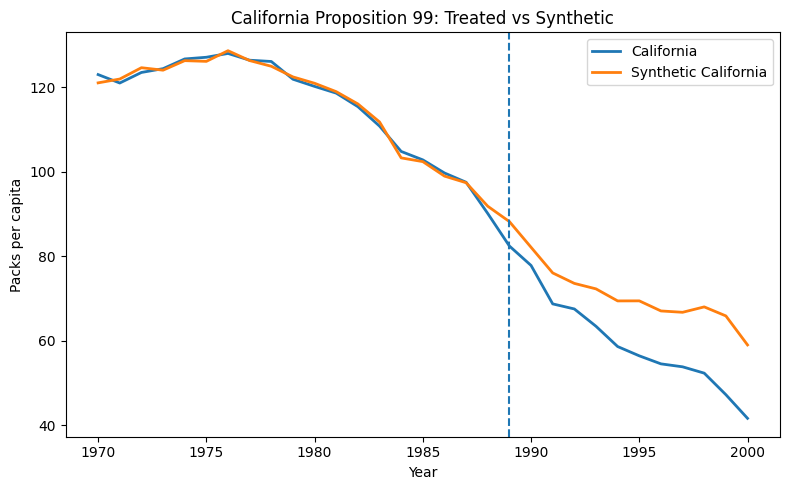

In [8]:


res_cal = cal_fit["results"]

plt.figure(figsize=(8, 5))
plt.plot(res_cal["Year"], res_cal["Treated"], label="California", linewidth=2)
plt.plot(res_cal["Year"], res_cal["Synthetic"], label="Synthetic California", linewidth=2)
plt.axvline(treatment_year, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Packs per capita")
plt.title("California Proposition 99: Treated vs Synthetic")
plt.legend()
plt.tight_layout()
plt.show()

## Randomization test


Number of successful placebo fits: 37
Some placebo fits failed:
  New Hampshire: New Hampshire: optimization failed: Positive directional derivative for linesearch

In-space randomization inference
California ratio = 12.5570
Randomization p-value = 0.0541


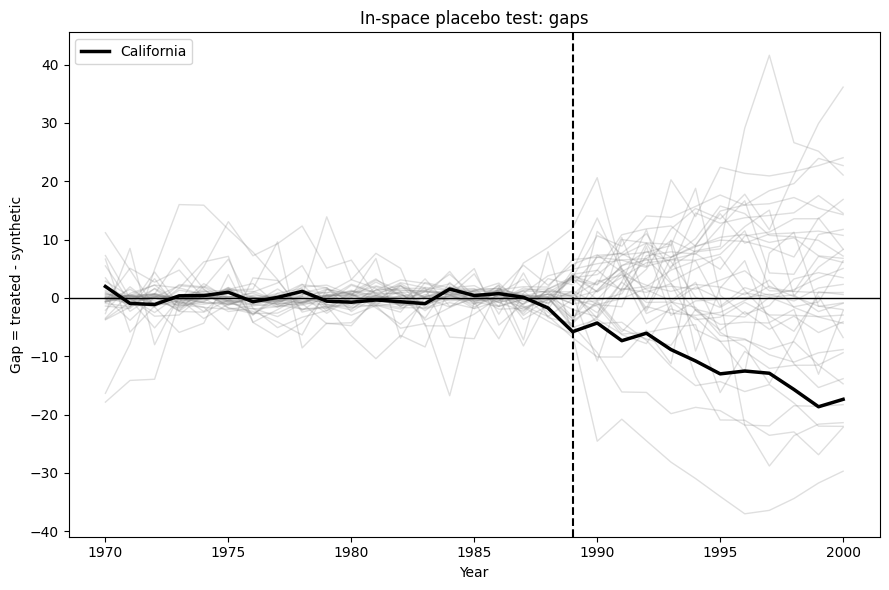

In [13]:


# ============================================================
# 4. In-space placebo fits
# ============================================================
all_states = sorted(df["State"].unique())
placebo_states = [s for s in all_states if s != treated_state]

placebo_fits = []
failed_states = []

for s in placebo_states:
    try:
        fit_s = fit_scm_with_intercept(df, s, treatment_year)
        placebo_fits.append(fit_s)
    except Exception as e:
        failed_states.append((s, str(e)))

print(f"\nNumber of successful placebo fits: {len(placebo_fits)}")
if failed_states:
    print("Some placebo fits failed:")
    for s, msg in failed_states[:10]:
        print(f"  {s}: {msg}")

# Summarize placebo ratios
placebo_summary = pd.DataFrame({
    "State": [x["treated_state"] for x in placebo_fits],
    "pre_rmspe": [x["pre_rmspe"] for x in placebo_fits],
    "post_rmspe": [x["post_rmspe"] for x in placebo_fits],
    "ratio": [x["ratio"] for x in placebo_fits],
})



# ============================================================
# 5. Randomization p-value
# ============================================================
# Exact permutation-style p-value based on rank of California
# among treated + placebo units.
p_value = np.mean(placebo_summary["ratio"] >= cal_fit["ratio"])

print("\nIn-space randomization inference")
print(f"California ratio = {cal_fit['ratio']:.4f}")
print(f"Randomization p-value = {p_value:.4f}")



# ============================================================
#6. Plot California gap + placebo gaps
# ============================================================
plt.figure(figsize=(9, 6))

# plot placebo gaps in gray
for fit_s in placebo_fits:
    res_s = fit_s["results"]
    plt.plot(res_s["Year"], res_s["Gap"], color="gray", alpha=0.25, linewidth=1)

# California in black
plt.plot(res_cal["Year"], res_cal["Gap"], color="black", linewidth=2.5, label="California")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(treatment_year, linestyle="--", color="black")
plt.xlabel("Year")
plt.ylabel("Gap = treated - synthetic")
plt.title("In-space placebo test: gaps")
plt.legend()
plt.tight_layout()
plt.show()
